In [ ]:
import random
random.seed(1000)
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


# Create Data

In [ ]:
# number of elements in list
n = 50

# list of unsorted items
items = [int(random.random()*n) for _ in range(n)]

# value to be searched in list
value = int(random.random()*n)

# sorted list 
sorted_items = sorted(items)

# Find Value in Unsorted List with Linear Search

Animation: https://yongdanielliang.github.io/animation/web/LinearSearchNew.html

In [ ]:
def get_item(items, index):
    """value of of an item in a list based on the index of the value
        args:
            - items: List of items
            - index: index of the requested item
        return:
            - value of the requested item
    """
    if index == -1:
        print("Not in the list")
        return None
    else:
        return items[index] 

In [ ]:
def find_element(items, value):
    """Linear search for a value in a list of items
        args:
            - items: unsorted list of items
            - value: searched value
        return:
            - index of value or -1 if not in list
    """
    for i, item in enumerate(items):
        if item == value:
            return i
    return -1

In [ ]:
index = find_element(items, value)
print(index)

36


In [ ]:
print(value)
get_item(items, index)

14


14

### Question: 
* Time your function with differently sized inputs by
* searching for each input size for a non-existing element
* and plot the change of the time to the size of the input

(see 1 Timing Algorithms)

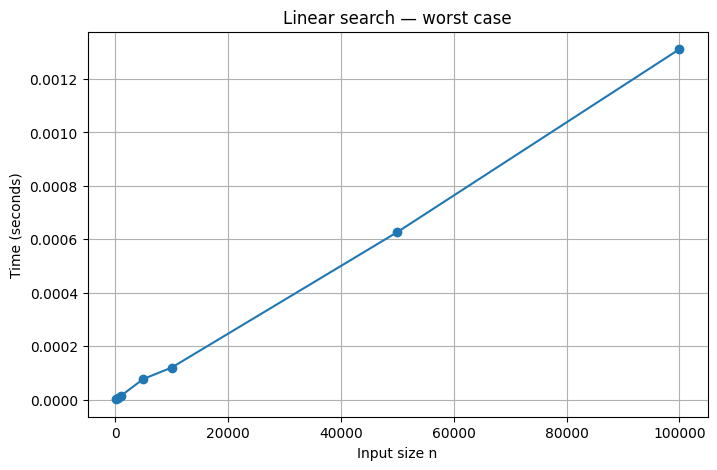

In [ ]:
import time

sizes = [100, 500, 1000, 5000, 10000, 50000, 100000]
linear_times = []

for size in sizes:
    test_items = [int(random.random() * size) for _ in range(size)]
    missing = size + 1  # non-existing -> worst case
    start = time.perf_counter()
    find_element(test_items, missing)
    linear_times.append(time.perf_counter() - start)

plt.figure(figsize=(8, 5))
plt.plot(sizes, linear_times, marker="o")
plt.xlabel("Input size n")
plt.ylabel("Time (seconds)")
plt.title("Linear search — worst case")
plt.grid(True)
plt.show()

### Question: What is the time complexity of searching for a value in an unsorted list?

Big O Notation

**O(n)** — linear. Worst case scans every element.

# Find Value in Sorted list with Binary Search

Animation: https://yongdanielliang.github.io/animation/web/BinarySearchNew.html

In [ ]:
def find_sorted(items, value):
    """Binary search for a value in a list of sorted items
        args:
            - items: sorted list of items
            - value: searched value
        return:
            - index of value or -1 if not in list
    """
    low, high = 0, len(items) - 1
    while low <= high:
        mid = (low + high) // 2
        if items[mid] == value:
            return mid
        elif items[mid] < value:
            low = mid + 1
        else:
            high = mid - 1
    return -1

In [ ]:
# a value that is not in the list so that we get the worst case time
value = n+1 
find_sorted(sorted_items, value)

-1

In [ ]:
n = 100
items = [int(random.random()*n) for _ in range(n)]
value = n+1 
find_sorted(sorted_items, value)

-1

In [ ]:
n = 200
items = [int(random.random()*n) for _ in range(n)]
value = n+1 
find_sorted(sorted_items, value)

-1

### Question: 
* Time your function with differently sized inputs by
* searching for each input size for a non-existing element
* and plot the change of the time to the size of the input

(see 1 Timing Algorithms)

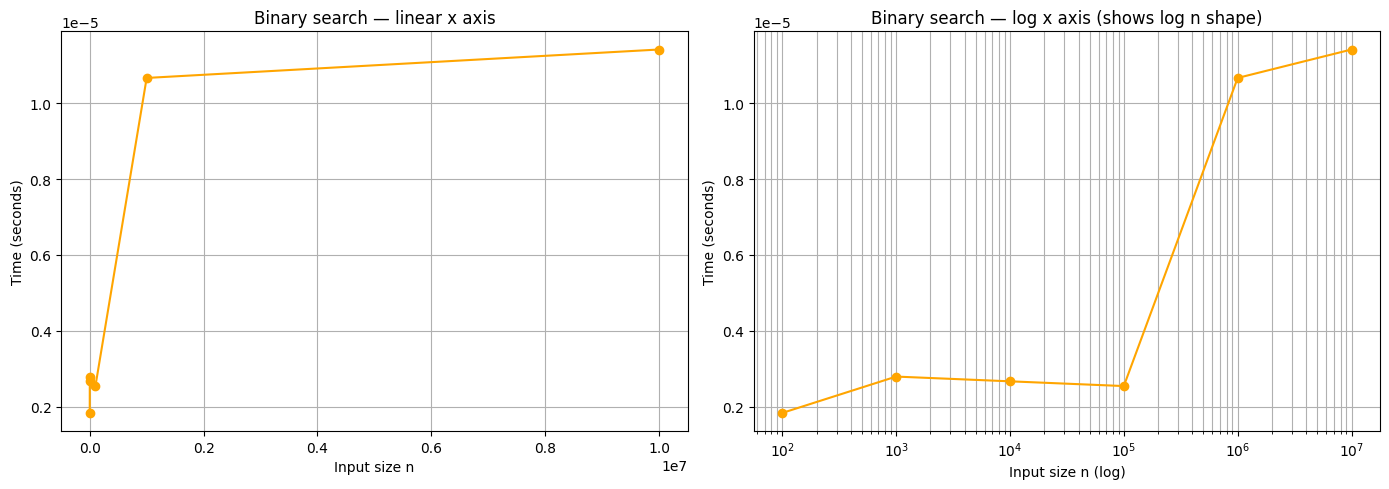

In [ ]:
binary_sizes = [100, 1000, 10000, 100000, 1000000, 10000000]
binary_times = []

for size in binary_sizes:
    test_items = sorted(int(random.random() * size) for _ in range(size))
    missing = size + 1  # non-existing -> worst case
    start = time.perf_counter()
    find_sorted(test_items, missing)
    binary_times.append(time.perf_counter() - start)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(binary_sizes, binary_times, marker="o", color="orange")
ax[0].set_xlabel("Input size n")
ax[0].set_ylabel("Time (seconds)")
ax[0].set_title("Binary search — linear x axis")
ax[0].grid(True)

ax[1].plot(binary_sizes, binary_times, marker="o", color="orange")
ax[1].set_xscale("log")
ax[1].set_xlabel("Input size n (log)")
ax[1].set_ylabel("Time (seconds)")
ax[1].set_title("Binary search — log x axis (shows log n shape)")
ax[1].grid(True, which="both")

plt.tight_layout()
plt.show()

### Question: What is the time complexity of binary search? 

Big O Notation

**O(log n)** — halves search range each step.